<a href="https://colab.research.google.com/github/RamyaSri2222/Data-Science/blob/main/stock_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-3622617834.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download( "AAPL" , start="2018-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


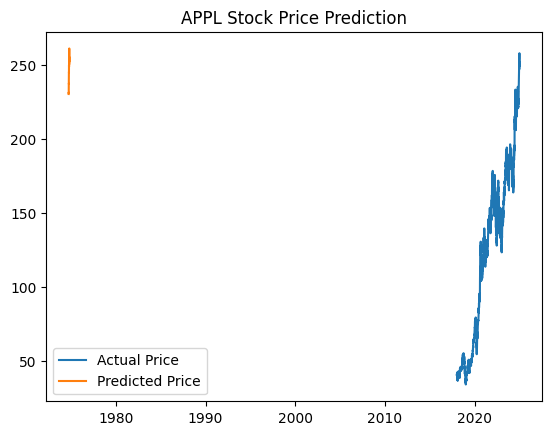

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Download stock data

data = yf.download( "AAPL" , start="2018-01-01", end="2025-01-01")

# Use closing price
data['Prediction'] = data['Close'].shift(-30)

# Features & labels
X = np.array(data[['Close']])[:-30]
y = np.array(data['Prediction'])[:-30]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict future prices
future_days = 30
future_prices = model.predict(np.array(data[['Close']])[-future_days:])

# Plot
plt.plot(data['Close'], label="Actual Price")
plt.plot(range(len(data)-future_days, len(data)), future_prices, label="Predicted Price")
plt.legend()
plt.title(f"{"APPL"} Stock Price Prediction")
plt.show()
